# Tree Equity Score - Exploratory Data Analysis

**Data Source:**
- `tree_equity_blockgroups`: Block group level tree equity data (6,363 records)
- `tree_equity_by_county`: County-level aggregated tree equity data

**Objectives:**
1. Understand tree canopy coverage across NJ counties
2. Analyze Tree Equity Score distribution
3. Identify areas with low tree coverage
4. Explore correlations with health and socioeconomic factors
5. Create combined environmental health index

**Note:** Tree Equity data is at Census block group level, aggregated to county level for joining with ZCTA-level CDC PLACES and Zillow data.

In [1]:
import duckdb
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Close any existing connection first
try:
    conn.close()
except:
    pass

# Connect to database
db_path = Path('../data/db/nj_pipeline.duckdb')
conn = duckdb.connect(str(db_path))
print(f"Connected to: {db_path}")

Connected to: ../data/db/nj_pipeline.duckdb


## 1. Data Overview

In [2]:
# Check available tables
tables = conn.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'main'
    AND table_name LIKE '%tree%'
""").df()

print("Available tree equity tables:")
display(tables)

# Load tree equity data if tables don't exist
if len(tables) == 0:
    print("\n⚠️  Tree equity tables not found. Loading from processed data...")
    
    PROCESSED_FILE = Path('../data/processed/tree_equity/tree_equity_nj_processed.csv')
    
    if not PROCESSED_FILE.exists():
        print(f"ERROR: Processed file not found at: {PROCESSED_FILE}")
        print("Please run: python scripts/ingest_tree_equity.py first")
    else:
        # Load the processed data
        print(f"Loading from: {PROCESSED_FILE}")
        df = pd.read_csv(PROCESSED_FILE)
        print(f"Loaded {len(df):,} block group records")
        
        # Create block group level table
        print("\nCreating tree_equity_blockgroups table...")
        conn.execute("DROP TABLE IF EXISTS tree_equity_blockgroups")
        conn.execute("CREATE TABLE tree_equity_blockgroups AS SELECT * FROM df")
        count = conn.execute("SELECT COUNT(*) FROM tree_equity_blockgroups").fetchone()[0]
        print(f"✓ Created tree_equity_blockgroups with {count:,} records")
        
        # Create county-level aggregation
        county_query = """
        CREATE OR REPLACE TABLE tree_equity_by_county AS
        SELECT
            county,
            COUNT(*) as num_block_groups,
            AVG(treecanopy) as avg_tree_canopy_pct,
            MIN(treecanopy) as min_tree_canopy_pct,
            MAX(treecanopy) as max_tree_canopy_pct,
            AVG(tes) as avg_tree_equity_score,
            MIN(tes) as min_tree_equity_score,
            MAX(tes) as max_tree_equity_score,
            AVG(priority_i) as avg_priority_index,
            AVG(pctpoc) as avg_pct_poc,
            AVG(pctpov) as avg_pct_poverty,
            AVG(temp_diff) as avg_temp_difference
        FROM tree_equity_blockgroups
        GROUP BY county
        ORDER BY county
        """

        conn.execute(county_query)
        print("✓ Created tree_equity_by_county table")

        # Verify
        result = conn.execute("SELECT COUNT(*) FROM tree_equity_by_county").fetchone()[0]
        print(f"✓ {result} counties loaded")
        
        print("\n✓ Tree equity data loaded successfully!")
        print("\nNOTE: Tree data is at block group level, aggregated to county level")
        print("Joins with ZCTA data (CDC PLACES, Zillow) will use county as the linking field")

,table_name
0,tree_equity_blockgroups


In [3]:
# Load and aggregate to county-level data
tree_data = conn.execute("""
                         SELECT county,
                                COUNT(*)        as num_block_groups,
                                AVG(treecanopy) as avg_tree_canopy,
                                AVG(tc_gap)     as avg_tc_gap,
                                AVG(priority_i) as avg_priority_index,
                                SUM(cbg_pop)    as total_population,
                                SUM(land_area)  as total_land_area
                         FROM tree_equity_blockgroups
                         GROUP BY county
                         ORDER BY county
""").df()

print(f"Total counties with tree data: {len(tree_data)}")
print(f"\nData structure:")
display(tree_data.head())

,county,num_block_groups,avg_tree_canopy,avg_tc_gap,avg_priority_index,total_population,total_land_area
0,Atlantic County,184,0.311112,0.187675,0.394939,233511.0,297.5293
1,Bergen County,788,0.314365,0.132332,0.359358,954575.0,562.1433
2,Burlington County,296,0.395325,0.125379,0.332631,416738.0,513.3479
3,Camden County,374,0.361388,0.134139,0.383261,516639.0,405.1191
4,Cape May County,100,0.215113,0.236125,0.331667,77548.0,150.0259


In [ ]:
# Summary statistics
print("Tree Canopy Coverage Statistics:")
display(tree_data[['avg_tree_canopy', 'avg_tc_gap', 'avg_priority_index']].describe())

print("\nCounty-Level Aggregated Metrics:")
display(tree_data[['num_block_groups', 'total_population', 'total_land_area']].describe())

## 2. Tree Canopy Coverage Distribution

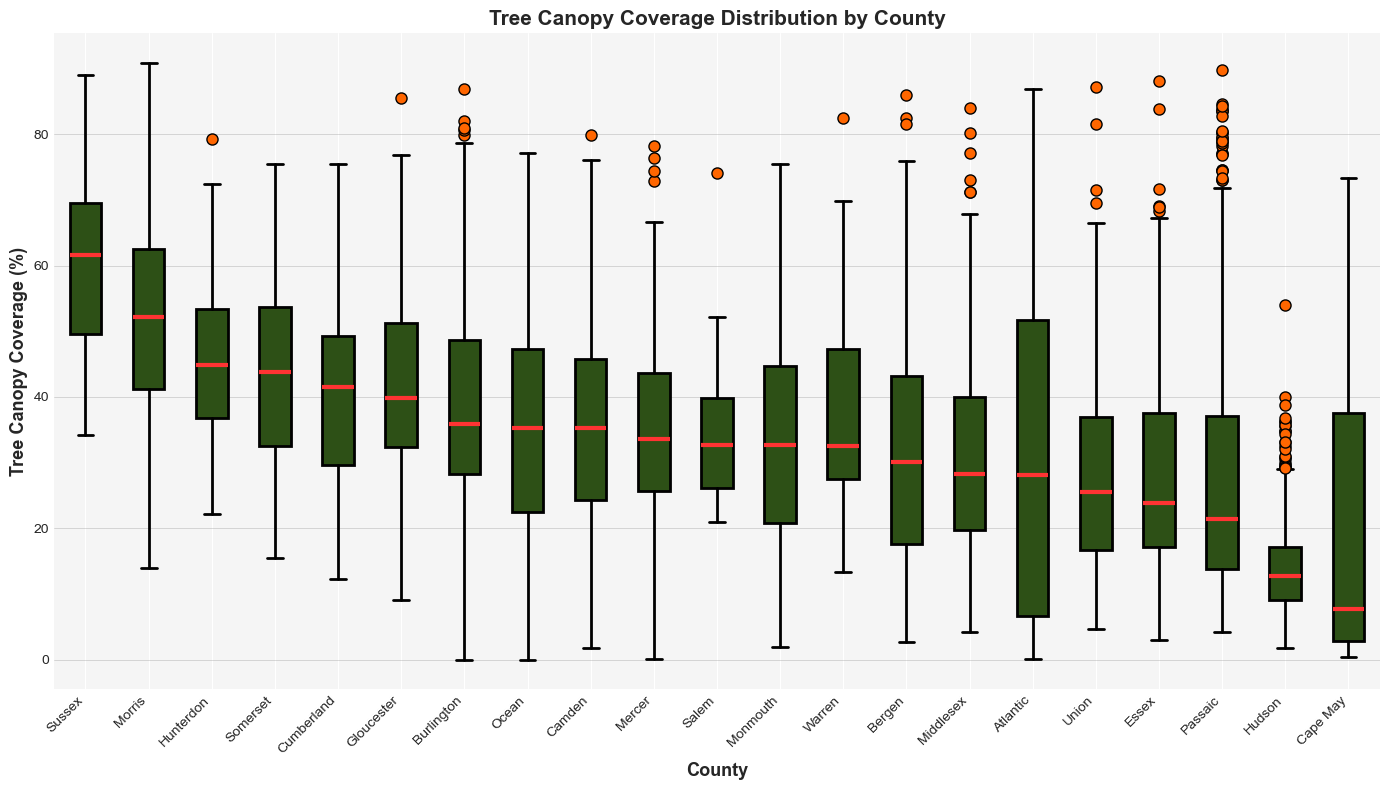

In [15]:
# Distribution of tree canopy coverage by county
tree_data['avg_tree_canopy_pct'] = tree_data['avg_tree_canopy'] * 100

fig, ax = plt.subplots(figsize=(14, 8))

# Get block group level data for boxplots
blockgroup_data = conn.execute("""
                               SELECT county, treecanopy * 100 as tree_canopy_pct
                               FROM tree_equity_blockgroups
                               ORDER BY county
                               """).df()

# Create boxplot by county
county_order = blockgroup_data.groupby('county')['tree_canopy_pct'].median().sort_values(ascending=False).index
blockgroup_data['county'] = pd.Categorical(blockgroup_data['county'], categories=county_order, ordered=True)

bp = ax.boxplot([blockgroup_data[blockgroup_data['county'] == county]['tree_canopy_pct'].dropna()
                 for county in county_order],
                labels=[c.replace(' County', '') for c in county_order],
                patch_artist=True,
                boxprops=dict(facecolor='#2d5016', color='black', linewidth=2),
                whiskerprops=dict(color='black', linewidth=2),
                capprops=dict(color='black', linewidth=2),
                medianprops=dict(color='#ff3333', linewidth=3),
                flierprops=dict(marker='o', markerfacecolor='#ff6600', markersize=8,
                                markeredgecolor='black', markeredgewidth=1))

ax.set_xlabel('County', fontsize=13, fontweight='bold')
ax.set_ylabel('Tree Canopy Coverage (%)', fontsize=13, fontweight='bold')
ax.set_title('Tree Canopy Coverage Distribution by County', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.4, color='gray', linestyle='-', linewidth=0.5, axis='y')
ax.set_facecolor('#f5f5f5')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 3. Tree Equity Score Analysis

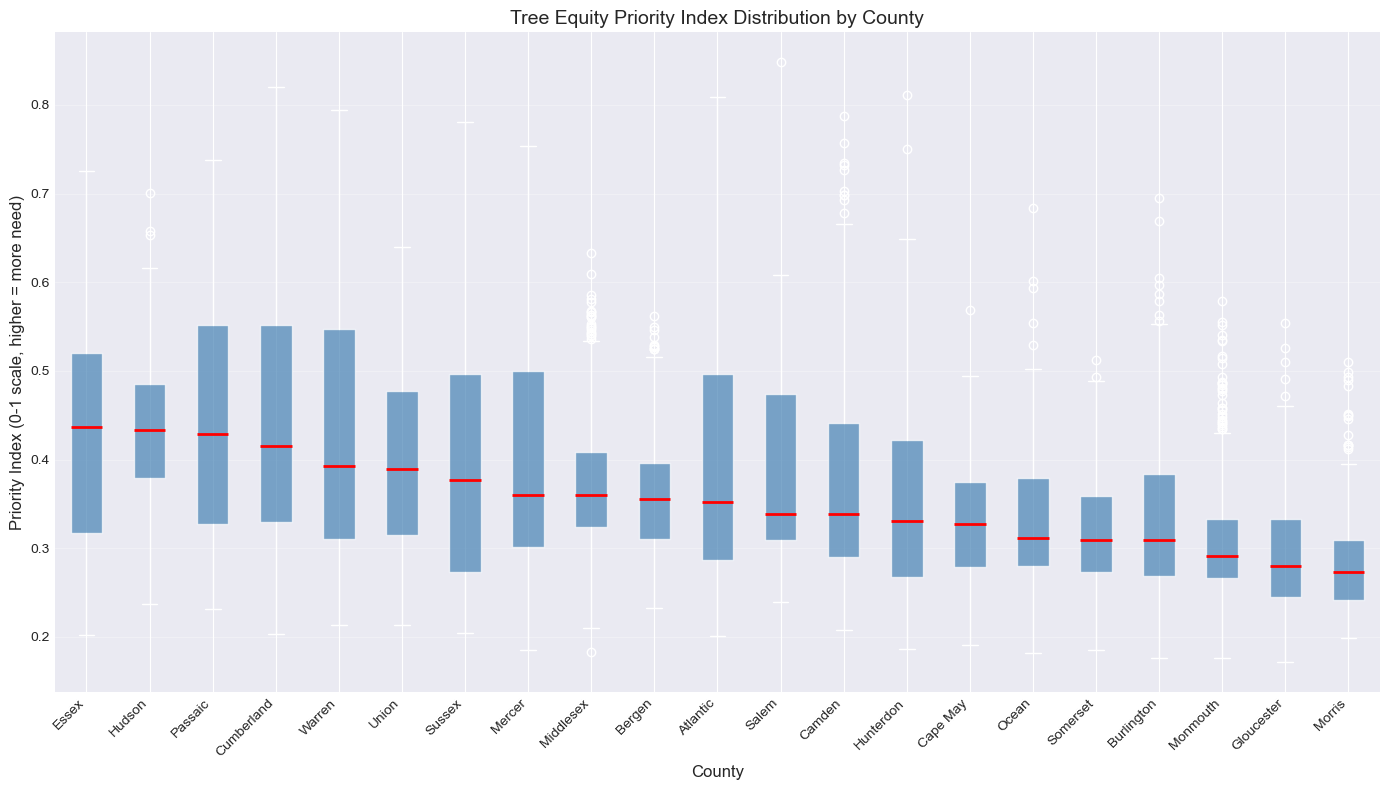

In [14]:
# Distribution of Priority Index by County (boxplots)
fig, ax = plt.subplots(figsize=(14, 8))

# Get block group level data for boxplots
blockgroup_data = conn.execute("""
                               SELECT county, treecanopy * 100 as tree_canopy_pct, priority_i
                               FROM tree_equity_blockgroups
                               ORDER BY county
                               """).df()

# Create boxplot by county
county_order = blockgroup_data.groupby('county')['priority_i'].median().sort_values(ascending=False).index
blockgroup_data['county'] = pd.Categorical(blockgroup_data['county'], categories=county_order, ordered=True)

bp = ax.boxplot([blockgroup_data[blockgroup_data['county'] == county]['priority_i'].dropna()
                 for county in county_order],
                labels=[c.replace(' County', '') for c in county_order],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))

ax.set_xlabel('County', fontsize=12)
ax.set_ylabel('Priority Index (0-1 scale, higher = more need)', fontsize=12)
ax.set_title('Tree Equity Priority Index Distribution by County', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 4. Geographic Analysis - Best and Worst Counties

In [13]:
# Top 10 counties with highest tree canopy coverage
print("Top 10 Counties - Highest Tree Canopy Coverage:")
print("=" * 60)
top_canopy = tree_data.nlargest(10, 'avg_tree_canopy_pct')[['county', 'num_block_groups', 'avg_tree_canopy_pct', 'avg_priority_index']]
for idx, row in top_canopy.iterrows():
    print(f"{row['county']}: {row['avg_tree_canopy_pct']:.1f}% canopy, Priority Index: {row['avg_priority_index']:.2f} ({row['num_block_groups']} block groups)")

Top 10 Counties - Highest Tree Canopy Coverage:
Sussex County: 60.4% canopy, Priority Index: 0.40 (75 block groups)
Morris County: 52.0% canopy, Priority Index: 0.28 (310 block groups)
Hunterdon County: 46.3% canopy, Priority Index: 0.37 (53 block groups)
Somerset County: 44.1% canopy, Priority Index: 0.32 (192 block groups)
Gloucester County: 42.0% canopy, Priority Index: 0.29 (206 block groups)
Cumberland County: 41.0% canopy, Priority Index: 0.44 (81 block groups)
Burlington County: 39.5% canopy, Priority Index: 0.33 (296 block groups)
Warren County: 37.6% canopy, Priority Index: 0.44 (48 block groups)
Camden County: 36.1% canopy, Priority Index: 0.38 (374 block groups)
Mercer County: 35.0% canopy, Priority Index: 0.40 (265 block groups)


In [ ]:
# Bottom 10 counties with lowest tree canopy coverage
print("\nBottom 10 Counties - Lowest Tree Canopy Coverage:")
print("=" * 60)
bottom_canopy = tree_data.nsmallest(10, 'avg_tree_canopy_pct')[['county', 'num_block_groups', 'avg_tree_canopy_pct', 'avg_priority_index']]
for idx, row in bottom_canopy.iterrows():
    print(f"{row['county']}: {row['avg_tree_canopy_pct']:.1f}% canopy, Priority Index: {row['avg_priority_index']:.2f} ({row['num_block_groups']} block groups)")

In [ ]:
# Priority areas (highest priority index indicates greatest need)
print("\nPriority Counties - Highest Tree Equity Priority Index:")
print("=" * 60)
priority = tree_data.nlargest(10, 'avg_priority_index')[['county', 'num_block_groups', 'avg_tree_canopy_pct', 'avg_priority_index']]
for idx, row in priority.iterrows():
    print(f"{row['county']}: {row['avg_tree_canopy_pct']:.1f}% canopy, Priority Index: {row['avg_priority_index']:.2f} ({row['num_block_groups']} block groups)")

## 5. Integration with Health Data

In [17]:
# Join with CDC PLACES health data using county
# Note: We need to aggregate tree data at county level first
combined = conn.execute("""
    WITH tree_county AS (
        SELECT 
            county,
            AVG(treecanopy) * 100 as avg_tree_canopy_pct,
            AVG(priority_i) as avg_priority_index
        FROM tree_equity_blockgroups
        GROUP BY county
    )
    SELECT 
        c.zcta,
        z.county,
        c.obesity,
        c.diabetes,
        c.bphigh,
        c.csmoking,
        c.depression,
        t.avg_tree_canopy_pct,
        t.avg_priority_index
    FROM cdc_places_wide c
    INNER JOIN zillow_latest z ON c.zcta = z.zip_code
    INNER JOIN tree_county t ON z.county = t.county
    WHERE c.year = 2023
""").df()

print(f"Combined dataset: {len(combined)} ZCTAs")
print("\nNOTE: Tree data aggregated at county level")
display(combined.head())

,zcta,county,obesity,diabetes,bphigh,csmoking,depression,avg_tree_canopy_pct,avg_priority_index
0,07001,Middlesex County,32.1,10.8,31.8,12.2,13.1,30.724566,0.372399
1,07002,Hudson County,29.1,10.6,30.9,12.1,16.0,14.117618,0.427631
2,07003,Essex County,25.8,9.3,26.1,9.8,15.8,27.740997,0.423583
3,07004,Essex County,22.6,8.6,28.4,8.9,17.1,27.740997,0.423583
4,07005,Morris County,23.0,8.7,30.9,8.9,15.4,52.030226,0.284060


In [18]:
# Correlation between tree canopy and health outcomes
health_measures = ['obesity', 'diabetes', 'bphigh', 'csmoking', 'depression']
tree_measures = ['avg_tree_canopy_pct', 'avg_priority_index']

corr_data = combined[health_measures + tree_measures].corr()

# Focus on correlations with tree measures
tree_health_corr = corr_data.loc[health_measures, tree_measures]

print("\nCorrelations: Tree Coverage vs. Health Outcomes")
print("=" * 70)
display(tree_health_corr.round(3))

,avg_tree_canopy_pct,avg_priority_index
obesity,-0.187,0.191
diabetes,-0.194,0.272
bphigh,0.060,-0.072
csmoking,-0.055,0.273
depression,0.304,0.059


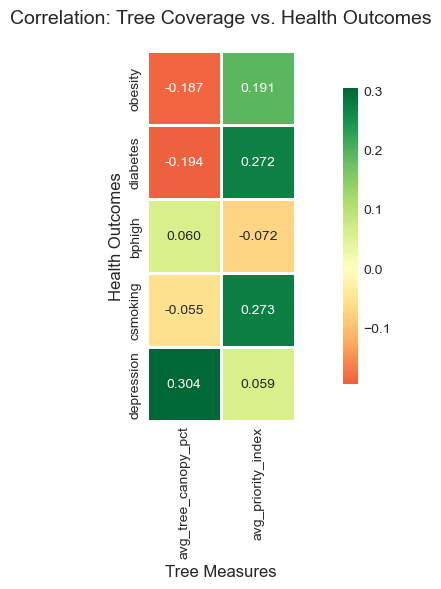

In [19]:
# Heatmap of correlations
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(tree_health_corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation: Tree Coverage vs. Health Outcomes', fontsize=14, pad=20)
ax.set_xlabel('Tree Measures', fontsize=12)
ax.set_ylabel('Health Outcomes', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Scatter Plots - Tree Coverage vs. Health

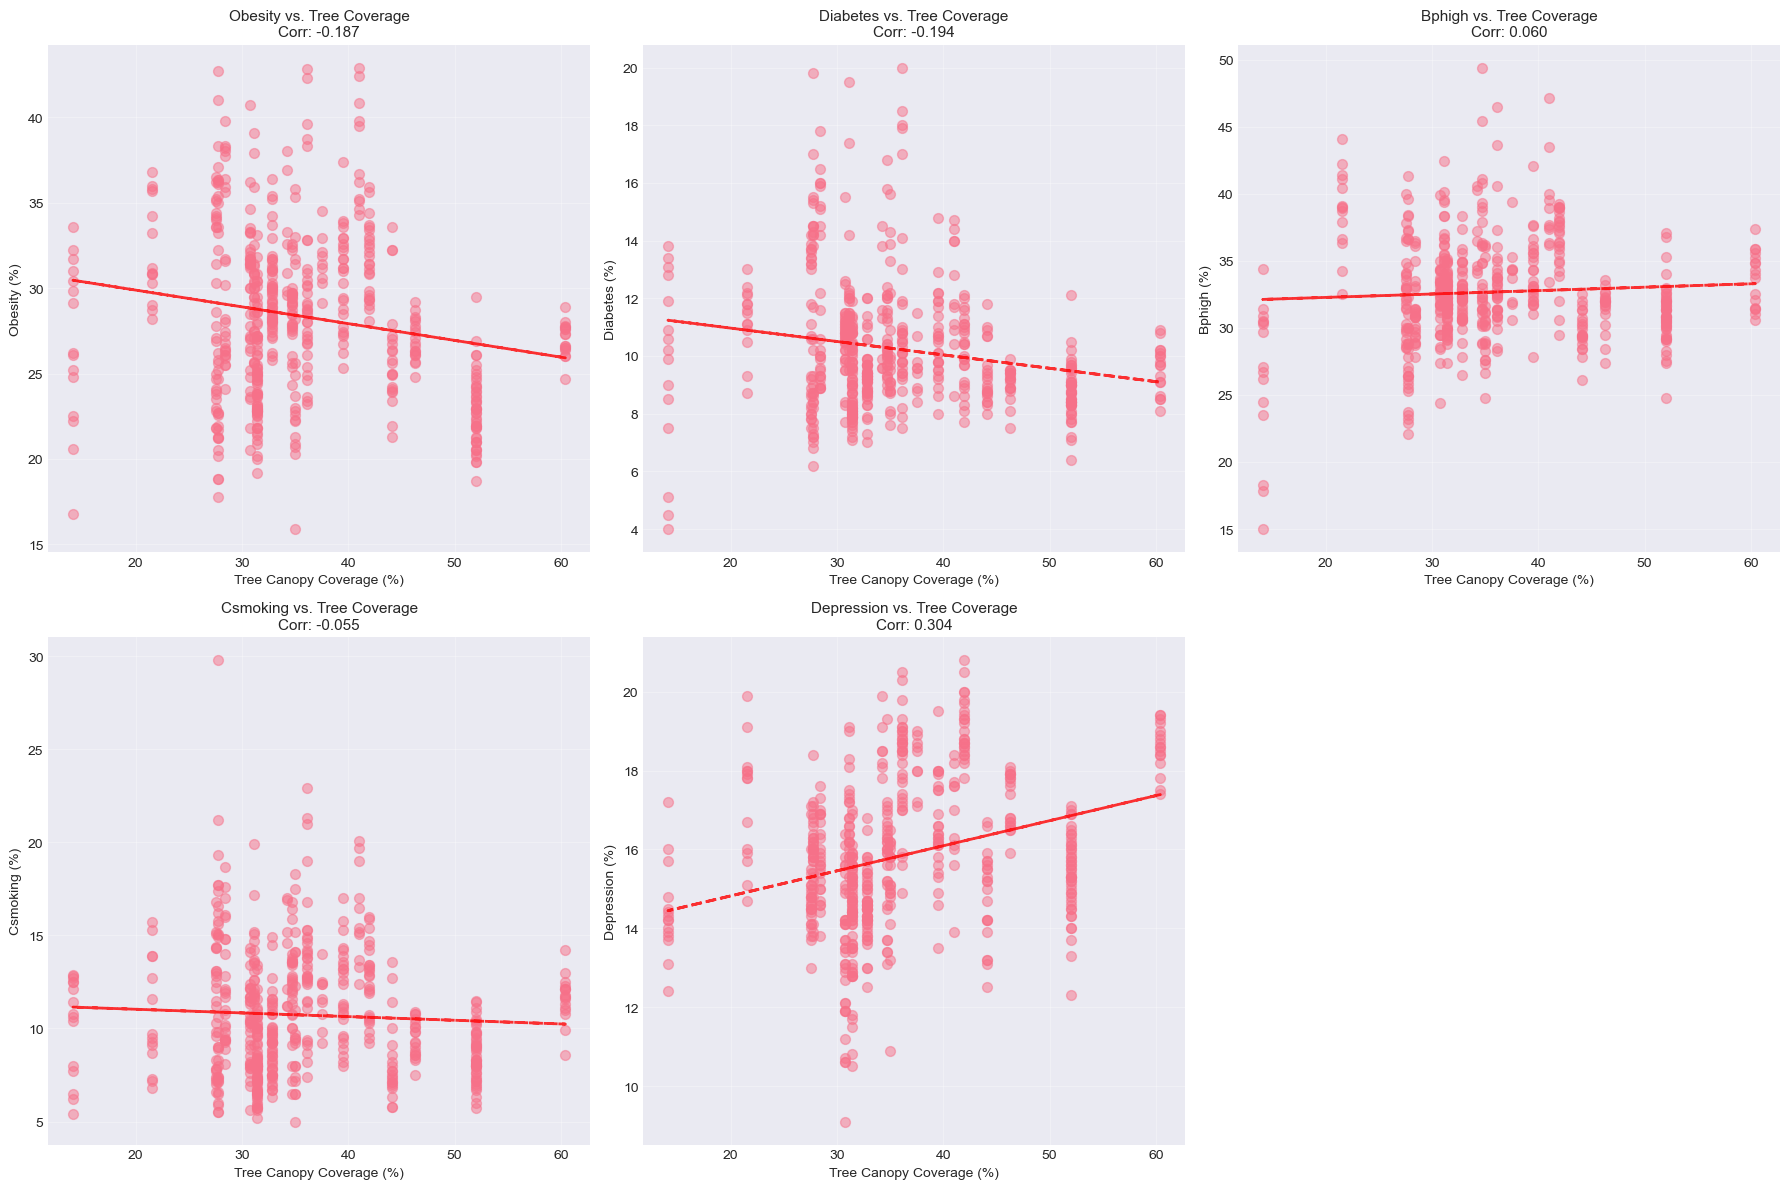

In [20]:
# Scatter plots for key health measures
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, health_measure in enumerate(health_measures):
    # Remove NaN values
    plot_data = combined[[health_measure, 'avg_tree_canopy_pct']].dropna()
    
    axes[idx].scatter(plot_data['avg_tree_canopy_pct'], 
                     plot_data[health_measure],
                     alpha=0.5, s=50)
    
    # Add trend line
    z = np.polyfit(plot_data['avg_tree_canopy_pct'], plot_data[health_measure], 1)
    p = np.poly1d(z)
    axes[idx].plot(plot_data['avg_tree_canopy_pct'], 
                  p(plot_data['avg_tree_canopy_pct']), 
                  "r--", linewidth=2, alpha=0.8)
    
    # Calculate correlation
    corr = plot_data['avg_tree_canopy_pct'].corr(plot_data[health_measure])
    
    axes[idx].set_xlabel('Tree Canopy Coverage (%)', fontsize=10)
    axes[idx].set_ylabel(f'{health_measure.capitalize()} (%)', fontsize=10)
    axes[idx].set_title(f'{health_measure.capitalize()} vs. Tree Coverage\nCorr: {corr:.3f}', 
                       fontsize=11)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

## 7. Integration with Zillow Home Values

In [21]:
# Join with Zillow data using county
tree_housing = conn.execute("""
    WITH tree_county AS (
        SELECT 
            county,
            AVG(treecanopy) * 100 as avg_tree_canopy_pct,
            AVG(priority_i) as avg_priority_index
        FROM tree_equity_blockgroups
        GROUP BY county
    )
    SELECT 
        z.zip_code,
        z.county,
        z.zhvi_latest,
        z.zori_latest,
        t.avg_tree_canopy_pct,
        t.avg_priority_index
    FROM zillow_latest z
    INNER JOIN tree_county t ON z.county = t.county
    WHERE z.zhvi_latest IS NOT NULL
""").df()

print(f"Combined tree and housing data: {len(tree_housing)} ZCTAs")
print("\nNOTE: Tree data aggregated at county level")
display(tree_housing.head())

BinderException: Binder Error: Values list "z" does not have a column named "zhvi_latest"

LINE 19:     WHERE z.zhvi_latest IS NOT NULL
                   ^

In [ ]:
# Tree canopy vs. home values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot - Home Values
plot_data = tree_housing[['avg_tree_canopy_pct', 'zhvi_latest']].dropna()
axes[0].scatter(plot_data['avg_tree_canopy_pct'], 
               plot_data['zhvi_latest'],
               alpha=0.5, s=50, color='darkgreen')

# Trend line
z = np.polyfit(plot_data['avg_tree_canopy_pct'], plot_data['zhvi_latest'], 1)
p = np.poly1d(z)
axes[0].plot(plot_data['avg_tree_canopy_pct'], 
            p(plot_data['avg_tree_canopy_pct']), 
            "r--", linewidth=2)

corr = plot_data['avg_tree_canopy_pct'].corr(plot_data['zhvi_latest'])
axes[0].set_xlabel('Tree Canopy Coverage (%)', fontsize=12)
axes[0].set_ylabel('Median Home Value ($)', fontsize=12)
axes[0].set_title(f'Tree Coverage vs. Home Values\nCorrelation: {corr:.3f}', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Scatter plot - Rent
plot_data2 = tree_housing[['avg_tree_canopy_pct', 'zori_latest']].dropna()
axes[1].scatter(plot_data2['avg_tree_canopy_pct'], 
               plot_data2['zori_latest'],
               alpha=0.5, s=50, color='olive')

# Trend line
z2 = np.polyfit(plot_data2['avg_tree_canopy_pct'], plot_data2['zori_latest'], 1)
p2 = np.poly1d(z2)
axes[1].plot(plot_data2['avg_tree_canopy_pct'], 
            p2(plot_data2['avg_tree_canopy_pct']), 
            "r--", linewidth=2)

corr2 = plot_data2['avg_tree_canopy_pct'].corr(plot_data2['zori_latest'])
axes[1].set_xlabel('Tree Canopy Coverage (%)', fontsize=12)
axes[1].set_ylabel('Median Rent ($)', fontsize=12)
axes[1].set_title(f'Tree Coverage vs. Rent\nCorrelation: {corr2:.3f}', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Environmental Health Index

In [22]:
# Create composite environmental health index
# Higher tree coverage = better (inverse)
# Higher health burden = worse

# Normalize tree coverage (0-100 scale, higher is better)
combined['tree_coverage_score'] = combined['avg_tree_canopy_pct']

# Calculate health burden (average of key measures, higher is worse)
combined['health_burden'] = combined[['obesity', 'diabetes', 'bphigh', 'csmoking', 'depression']].mean(axis=1)

# Environmental health index (tree coverage benefit minus health burden)
# Normalize both to 0-100 scale
tree_norm = (combined['tree_coverage_score'] - combined['tree_coverage_score'].min()) / \
            (combined['tree_coverage_score'].max() - combined['tree_coverage_score'].min()) * 100

health_norm = (combined['health_burden'] - combined['health_burden'].min()) / \
              (combined['health_burden'].max() - combined['health_burden'].min()) * 100

# Environmental Health Index (higher tree coverage = positive, higher health burden = negative)
combined['env_health_index'] = tree_norm - health_norm

print("Environmental Health Index Statistics:")
print(combined['env_health_index'].describe())

Environmental Health Index Statistics:
count    546.000000
mean       0.637364
std       24.731225
min      -70.575590
25%      -12.101715
50%       -2.127433
75%        9.586733
max       62.409138
Name: env_health_index, dtype: float64


In [23]:
# Best and worst areas by environmental health index
print("\nBest Environmental Health (High Tree Coverage + Low Health Burden):")
print("=" * 70)
best = combined.nlargest(10, 'env_health_index')[['zcta', 'county', 'avg_tree_canopy_pct', 'health_burden', 'env_health_index']]
display(best)


,zcta,county,avg_tree_canopy_pct,health_burden,env_health_index
90,07114,Essex County,27.740997,29.98,-70.575590
85,07108,Essex County,27.740997,27.20,-56.141529
395,08251,Cape May County,21.511300,24.48,-55.474186
100,07305,Hudson County,14.117618,21.20,-54.413292
396,08260,Cape May County,21.511300,24.16,-53.812712
72,07087,Hudson County,14.117618,21.02,-53.478712
390,08242,Cape May County,21.511300,23.76,-51.735869
397,08270,Cape May County,21.511300,23.70,-51.424342
76,07093,Hudson County,14.117618,20.52,-50.882658
99,07304,Hudson County,14.117618,20.30,-49.740395


In [24]:

print("\nWorst Environmental Health (Low Tree Coverage + High Health Burden):")
print("=" * 70)
worst = combined.nsmallest(10, 'env_health_index')[['zcta', 'county', 'avg_tree_canopy_pct', 'health_burden', 'env_health_index']]
display(worst)

,zcta,county,avg_tree_canopy_pct,health_burden,env_health_index
90,07114,Essex County,27.740997,29.98,-70.575590
85,07108,Essex County,27.740997,27.20,-56.141529
395,08251,Cape May County,21.511300,24.48,-55.474186
100,07305,Hudson County,14.117618,21.20,-54.413292
396,08260,Cape May County,21.511300,24.16,-53.812712
72,07087,Hudson County,14.117618,21.02,-53.478712
390,08242,Cape May County,21.511300,23.76,-51.735869
397,08270,Cape May County,21.511300,23.70,-51.424342
76,07093,Hudson County,14.117618,20.52,-50.882658
99,07304,Hudson County,14.117618,20.30,-49.740395


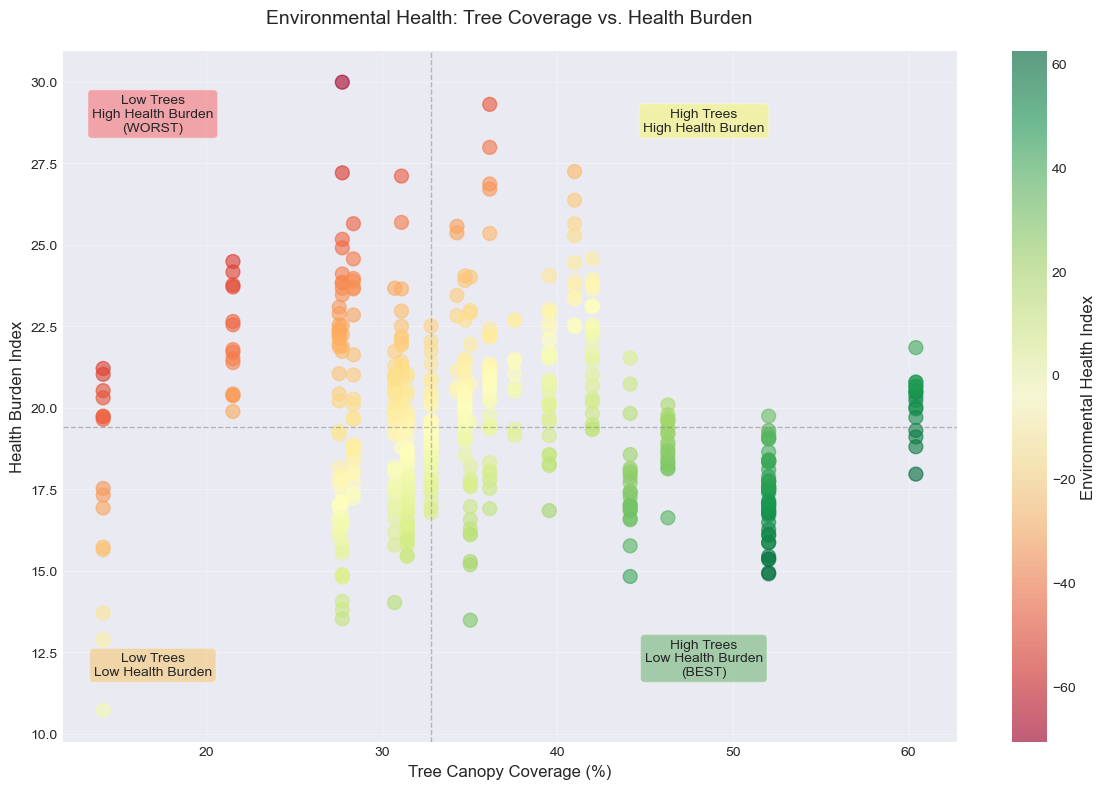

In [25]:
# Scatter plot: Tree Coverage vs. Health Burden
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(combined['avg_tree_canopy_pct'], 
                    combined['health_burden'],
                    c=combined['env_health_index'],
                    cmap='RdYlGn',
                    s=100,
                    alpha=0.6)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Environmental Health Index', fontsize=12)

# Add quadrant lines
ax.axhline(combined['health_burden'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(combined['avg_tree_canopy_pct'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Labels for quadrants
ax.text(combined['avg_tree_canopy_pct'].max() * 0.8, 
       combined['health_burden'].max() * 0.95,
       'High Trees\nHigh Health Burden',
       ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax.text(combined['avg_tree_canopy_pct'].max() * 0.8, 
       combined['health_burden'].min() * 1.1,
       'High Trees\nLow Health Burden\n(BEST)',
       ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))

ax.text(combined['avg_tree_canopy_pct'].min() * 1.2, 
       combined['health_burden'].max() * 0.95,
       'Low Trees\nHigh Health Burden\n(WORST)',
       ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

ax.text(combined['avg_tree_canopy_pct'].min() * 1.2, 
       combined['health_burden'].min() * 1.1,
       'Low Trees\nLow Health Burden',
       ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))

ax.set_xlabel('Tree Canopy Coverage (%)', fontsize=12)
ax.set_ylabel('Health Burden Index', fontsize=12)
ax.set_title('Environmental Health: Tree Coverage vs. Health Burden', fontsize=14, pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Key Findings Summary

In [26]:
print("=" * 70)
print("KEY FINDINGS - TREE EQUITY ANALYSIS")
print("=" * 70)

print(f"\n1. TREE CANOPY COVERAGE")
print(f"   • Mean coverage: {tree_data['avg_tree_canopy_pct'].mean():.1f}%")
print(f"   • Median coverage: {tree_data['avg_tree_canopy_pct'].median():.1f}%")
print(f"   • Range: {tree_data['avg_tree_canopy_pct'].min():.1f}% - {tree_data['avg_tree_canopy_pct'].max():.1f}%")

print(f"\n2. TREE EQUITY PRIORITY INDEX")
print(f"   • Mean index: {tree_data['avg_priority_index'].mean():.2f}")
print(f"   • Median index: {tree_data['avg_priority_index'].median():.2f}")
print(f"   • Counties with high priority (>0.4): {(tree_data['avg_priority_index'] > 0.4).sum()} ({(tree_data['avg_priority_index'] > 0.4).sum() / len(tree_data) * 100:.1f}%)")

if len(combined) > 0:
    print(f"\n3. HEALTH CORRELATIONS")
    for measure in health_measures:
        corr = combined['avg_tree_canopy_pct'].corr(combined[measure])
        print(f"   • {measure.capitalize()}: {corr:.3f}")
    
    print(f"\n4. ENVIRONMENTAL HEALTH INDEX")
    print(f"   • Mean: {combined['env_health_index'].mean():.1f}")
    print(f"   • Best ZCTA: {combined.nlargest(1, 'env_health_index')['zcta'].values[0]} (Score: {combined['env_health_index'].max():.1f})")
    print(f"   • Worst ZCTA: {combined.nsmallest(1, 'env_health_index')['zcta'].values[0]} (Score: {combined['env_health_index'].min():.1f})")

print("\n" + "=" * 70)

KEY FINDINGS - TREE EQUITY ANALYSIS

1. TREE CANOPY COVERAGE
   • Mean coverage: 35.6%
   • Median coverage: 34.7%
   • Range: 14.1% - 60.4%

2. TREE EQUITY PRIORITY INDEX
   • Mean index: 0.37
   • Median index: 0.38
   • Counties with high priority (>0.4): 7 (33.3%)

3. HEALTH CORRELATIONS
   • Obesity: -0.187
   • Diabetes: -0.194
   • Bphigh: 0.060
   • Csmoking: -0.055
   • Depression: 0.304

4. ENVIRONMENTAL HEALTH INDEX
   • Mean: 0.6
   • Best ZCTA: 07871 (Score: 62.4)
   • Worst ZCTA: 07114 (Score: -70.6)



In [27]:
conn.close()